# 02 - EDA Analysis
Explore sales, profit, customer, and return behavior.

✅ Đã tải xong thư viện vẽ biểu đồ!
Đang tải dữ liệu Master Sales...
📊 Dữ liệu sẵn sàng: 56,046 dòng và 45 cột.


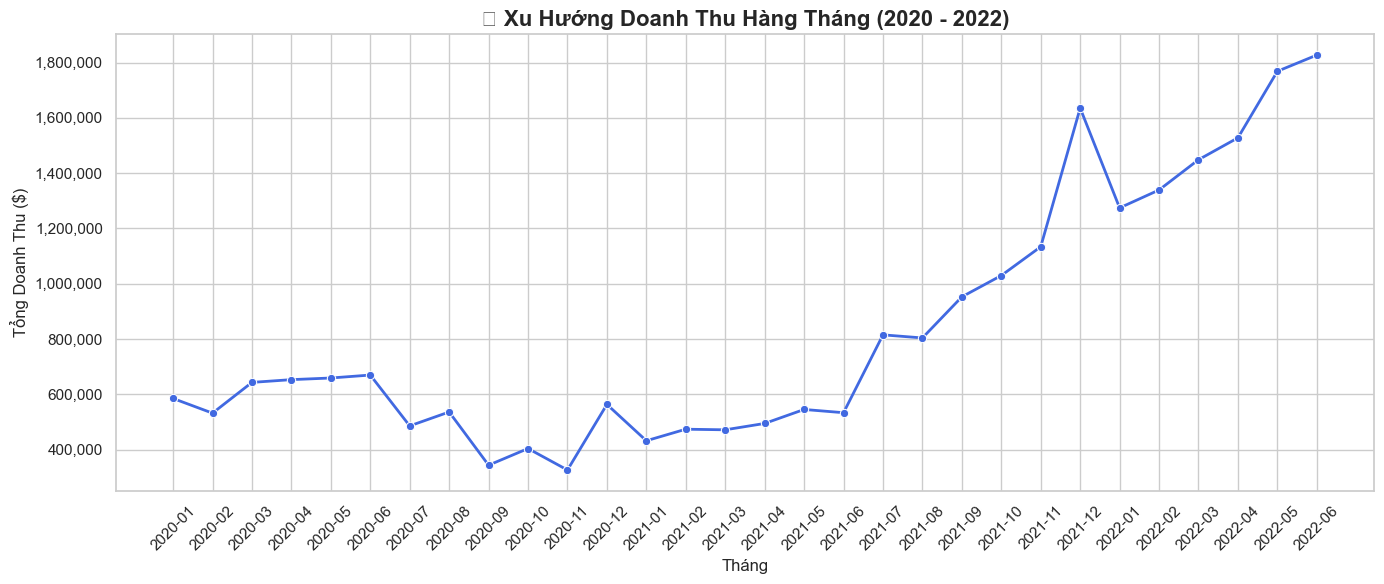

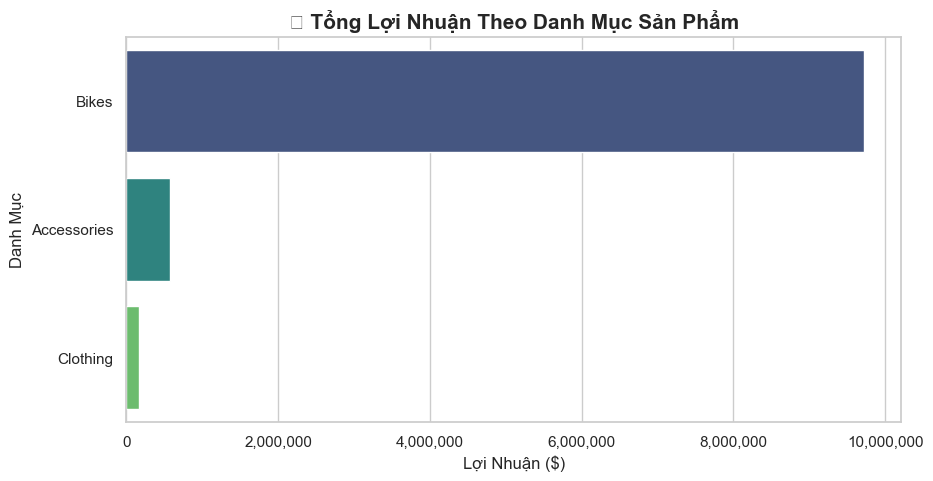

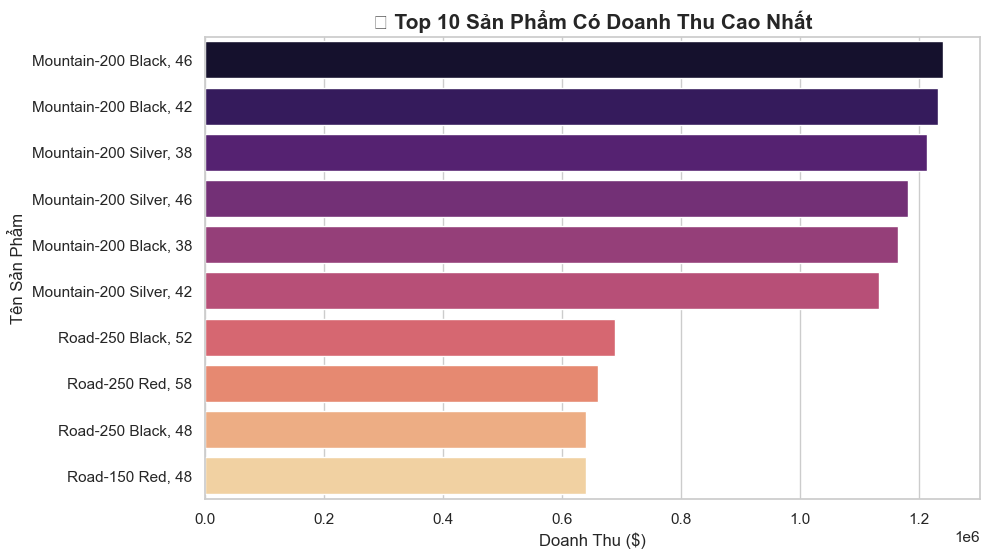

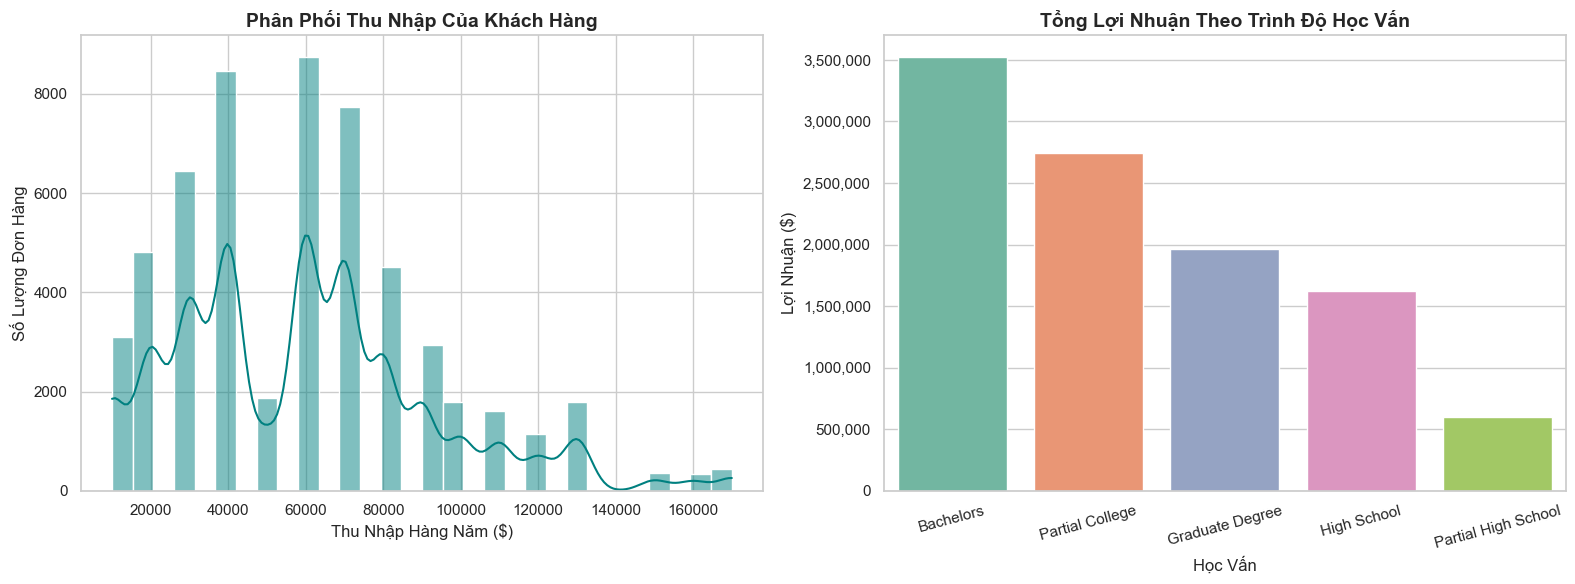

✅ ĐÃ HOÀN THÀNH VẼ TOÀN BỘ BIỂU ĐỒ!


In [1]:
# =====================================================================
# CELL 1: IMPORT THƯ VIỆN & CẤU HÌNH GIAO DIỆN
# =====================================================================
%matplotlib inline 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Tắt các cảnh báo vặt và thiết lập giao diện biểu đồ chuyên nghiệp
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Đã tải xong thư viện vẽ biểu đồ!")

# =====================================================================
# CELL 2: TẢI & CHUẨN BỊ DỮ LIỆU
# =====================================================================
print("Đang tải dữ liệu Master Sales...")
df = pd.read_csv('../data/processed/master_sales.csv')

# Ép kiểu ngày tháng và tạo cột Year-Month để vẽ chuỗi thời gian
df['orderdate'] = pd.to_datetime(df['orderdate'])
df['year_month'] = df['orderdate'].dt.to_period('M')

print(f"📊 Dữ liệu sẵn sàng: {df.shape[0]:,} dòng và {df.shape[1]} cột.")


# =====================================================================
# CELL 3: PHÂN TÍCH XU HƯỚNG DOANH THU HÀNG THÁNG
# =====================================================================
monthly_revenue = df.groupby('year_month')['revenue'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x='year_month', y='revenue', marker='o', color='royalblue', linewidth=2)

plt.title('📈 Xu Hướng Doanh Thu Hàng Tháng (2020 - 2022)', fontsize=16, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng Doanh Thu ($)', fontsize=12)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()


# =====================================================================
# CELL 4: PHÂN TÍCH SẢN PHẨM & DANH MỤC LỢI NHUẬN CAO NHẤT
# =====================================================================
# 4.1 Lợi nhuận theo Danh mục
category_profit = df.groupby('categoryname')['profit'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=category_profit, x='profit', y='categoryname', palette='viridis')
plt.title('🏆 Tổng Lợi Nhuận Theo Danh Mục Sản Phẩm', fontsize=15, fontweight='bold')
plt.xlabel('Lợi Nhuận ($)', fontsize=12)
plt.ylabel('Danh Mục', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

# 4.2 Top 10 Sản phẩm Doanh thu cao nhất
top_products = df.groupby('productname')['revenue'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='revenue', y='productname', palette='magma')
plt.title('🔥 Top 10 Sản Phẩm Có Doanh Thu Cao Nhất', fontsize=15, fontweight='bold')
plt.xlabel('Doanh Thu ($)', fontsize=12)
plt.ylabel('Tên Sản Phẩm', fontsize=12)
plt.show()


# =====================================================================
# CELL 5: CHÂN DUNG KHÁCH HÀNG (Thu nhập & Học vấn)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Phân phối Thu nhập
sns.histplot(df['annualincome'], bins=30, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Phân Phối Thu Nhập Của Khách Hàng', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Thu Nhập Hàng Năm ($)')
axes[0].set_ylabel('Số Lượng Đơn Hàng')

# Lợi nhuận theo Trình độ học vấn
edu_profit = df.groupby('educationlevel')['profit'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=edu_profit, x='educationlevel', y='profit', palette='Set2', ax=axes[1])
axes[1].set_title('Tổng Lợi Nhuận Theo Trình Độ Học Vấn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Học Vấn')
axes[1].set_ylabel('Lợi Nhuận ($)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

print("✅ ĐÃ HOÀN THÀNH VẼ TOÀN BỘ BIỂU ĐỒ!")